In [7]:
import SensoriMotorPrediction.globals as gl
import os
import pandas as pd
import numpy as np 
import seaborn as sb
import matplotlib.pyplot as plt
from SensoriMotorPrediction.vis import plot_binned_finger_cue
from SensoriMotorPrediction.util import anova_finger_cue

Perturbation,Source,F,DF,p-unc
index,cue,3.476888,3,0.024888
index,Error,nan,39,nan
ring,cue,0.633799,3,0.598064
ring,Error,nan,36,nan


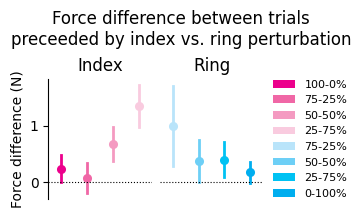

In [12]:
experiment='smp2'

filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )

prev = 1
dat_index_prev = dat[dat.stimFinger_prev1=='index']
dat_ring_prev = dat[dat.stimFinger_prev1=='ring']
dat_index_cue_prev = dat_index_prev.groupby(['sn', f'cue', 'stimFinger']).mean(numeric_only=True).reset_index()
dat_ring_cue_prev = dat_ring_prev.groupby(['sn', f'cue', 'stimFinger']).mean(numeric_only=True).reset_index()
dat_diff = dat_index_cue_prev.merge(dat_ring_cue_prev, on=['sn', f'cue', 'stimFinger'], suffixes=['_index', '_ring'])
dat_diff['index1_diff'] = dat_diff.index1_index - dat_diff.index1_ring
dat_diff['ring1_diff'] = dat_diff.ring1_index - dat_diff.ring1_ring

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(3.5, 2), constrained_layout=True)

plot_binned_finger_cue(fig, axs, dat_diff, x=f'cue', y=('index1_diff', 'ring1_diff'), finger=('index', 'ring'), show_individuals=False)
# axs[0].spines[['left']].set_bounds(-5, 5)
# axs[0].set_ylim(-5.5, 5.5)
axs[0].axhline(0, color='k', lw=.8, ls=":")
axs[1].axhline(0, color='k', lw=.8, ls=":")
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(left=False)
axs[0].set_ylabel('Force difference (N)')
axs[0].set_title('Index')
axs[1].set_title('Ring')
fig.suptitle('Force difference between trials\npreceeded by index vs. ring perturbation')

anova_finger_cue(dat_diff, dv=('index1_diff', 'ring1_diff'), within=f'cue')

plt.show()

Perturbation,Source,F,DF,p-unc
index,cue_prev1,0.505052,2,0.609274
index,Error,nan,26,nan
ring,cue_prev1,0.881396,2,0.428329
ring,Error,nan,22,nan


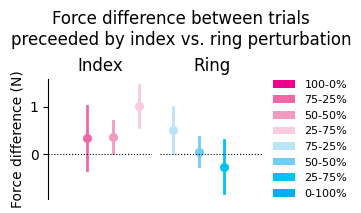

In [13]:
experiment='smp2'

filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )

prev = 1
dat_index_prev = dat[dat.stimFinger_prev1=='index']
dat_ring_prev = dat[dat.stimFinger_prev1=='ring']
dat_index_cue_prev = dat_index_prev.groupby(['sn', f'cue_prev{prev}', 'stimFinger']).mean(numeric_only=True).reset_index()
dat_ring_cue_prev = dat_ring_prev.groupby(['sn', f'cue_prev{prev}', 'stimFinger']).mean(numeric_only=True).reset_index()
dat_diff = dat_index_cue_prev.merge(dat_ring_cue_prev, on=['sn', f'cue_prev{prev}', 'stimFinger'], suffixes=['_index', '_ring'])
dat_diff['index1_diff'] = dat_diff.index1_index - dat_diff.index1_ring
dat_diff['ring1_diff'] = dat_diff.ring1_index - dat_diff.ring1_ring

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(3.5, 2), constrained_layout=True)

plot_binned_finger_cue(fig, axs, dat_diff, x=f'cue_prev{prev}', y=('index1_diff', 'ring1_diff'), finger=('index', 'ring'), show_individuals=False)
# axs[0].spines[['left']].set_bounds(-5, 5)
# axs[0].set_ylim(-5.5, 5.5)
axs[0].axhline(0, color='k', lw=.8, ls=":")
axs[1].axhline(0, color='k', lw=.8, ls=":")
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(left=False)
axs[0].set_ylabel('Force difference (N)')
axs[0].set_title('Index')
axs[1].set_title('Ring')
fig.suptitle('Force difference between trials\npreceeded by index vs. ring perturbation')

anova_finger_cue(dat_diff, dv=('index1_diff', 'ring1_diff'), within=f'cue_prev{prev}')

plt.show()